### Linear Regression Model

##### Importing numpy and pandas libraries to read the data

In [1]:
import numpy as np
import pandas as pd

##### Suppress warnings

In [2]:
import warnings
warnings.filterwarnings('ignore')

##### Read the given CSV file, and view some sample records.

In [3]:
advertising = pd.read_csv("Company_data.csv")
advertising

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


##### Our target variable is the Sales column.

The dataset Company_data.csv contains four numerical columns:

TV – Amount spent on TV advertising (in thousands of dollars).

Radio – Amount spent on radio advertising (in thousands of dollars).

Newspaper – Amount spent on newspaper advertising (in thousands of dollars).

Sales – Total sales (in thousands of units or dollars).

This appears to be a dataset used for analyzing the impact of advertising spending on sales.

#### Understand the data: pandas library has shape, info(), describe() methods:

In [4]:
# Shape of our dataset
advertising.shape

(200, 4)

In [5]:
# Info of our dataset
advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


Using the info, we can see whether there are any null values in the data.
If yes, then we have to do some data manipulation.

In [6]:
# Describe our dataset
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


##### 
If the DataFrame contains numerical data, the description contains these information for each column:

count - The number of not-empty values.

mean - The average (mean) value.

std - The standard deviation.

min - the minimum value.

25% - The 25% percentile*.

50% - The 50% percentile*.

75% - The 75% percentile*.

max - the maximum value.

*Percentile meaning: how many of the values are less than the given percentile.

#### Visualizing the data by matplotlib and seaborn libraries:

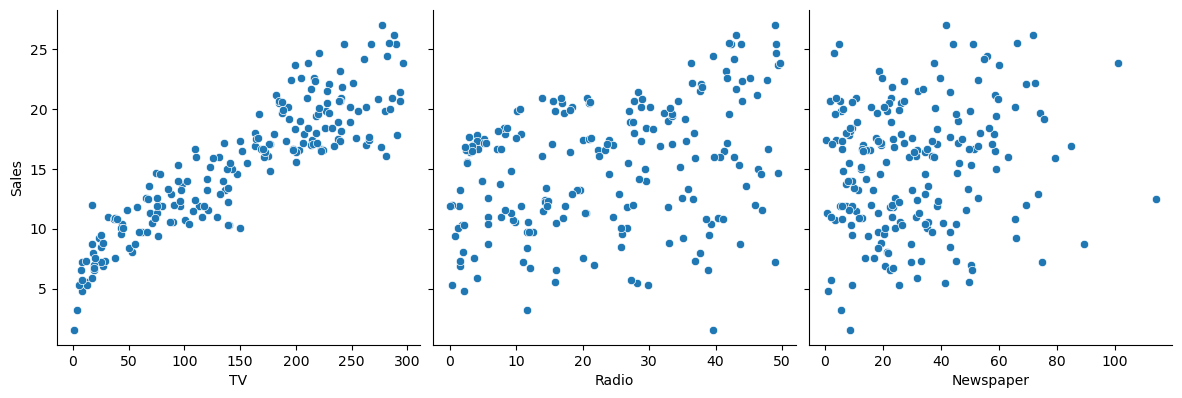

In [7]:
# Import matplotlib and seaborn libraries to visualize the data.
import matplotlib.pyplot as plt 
import seaborn as sns

# Using pairplot, visualize the data for correlation, better to use a scatter plot
# between two numeric variables.
sns.pairplot(advertising, x_vars=['TV', 'Radio','Newspaper'], 
             y_vars='Sales', size=4, aspect=1, kind='scatter')
plt.show()

We can see better correlation between TV and Sales here as they tend to create a line diagonal and the others are more like spread through the graph.

The scatter plot with a regression line shows that higher TV ad spending is generally associated with higher sales.

If we cannot determine the correlation using a scatter plot, we can use the seaborn heatmap to visualize the data.

You can customize the colors in your heatmap with the cmap parameter of the heatmap() function in seaborn.

Let’s pick one of the sequential colormaps YlGnBu.

YlGnBu is a color palette that's part of the Rcolorbrewer package. It's a sequential palette, which means it uses colors that progress from low to high. YlGnBu is a part-spectral palette, which means it uses colors that are part of the spectrum, like yellow and green. 

YlGnBu is used in visualizations to represent ordered data, like risk levels. 
The light colors in YlGnBu have low chroma, which helps signal low risk. 
YlGnBu is part of a group of palettes called the Brewer palettes, which also include Blues, BuGn, Greens, and Greys. 

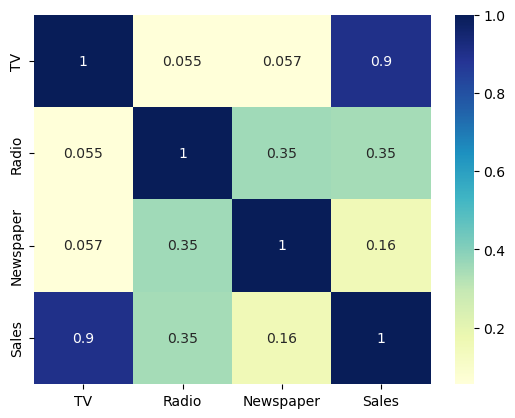

In [8]:
# Visualizing the data using heatmap
sns.heatmap(advertising.corr(), cmap="YlGnBu", annot = True)
plt.show()

As we can see from the above graphs, the TV column seems most correlated to Sales (0.9).

The correlation between TV advertising spend and sales is 0.90, indicating a strong positive relationship.

#### Performing Simple Linear Regression
In cell 9:
Creating X and y:

assign our feature variable/column TV as X and our target variable Sales as y.

The independent variable represents X, and y represents the target variable in a simple linear regression model.

Equation of simple linear regression y = c + mX.

In our case:

Sales = c + m * TV

The m and c values are known as slope and intercept, respectively.

In cell 10:

Splitting the variables as training and testing:

Use scikit-learn library: Simple and efficient tools for predictive data analysis.

Using the training set, build the model and perform the model on the testing set.

divide the training and testing sets into a 7:3 ratio, respectively.

Remember we have 200 data in total and training set is 70% which makes it 140 data items.

In cells 11-12 we can observe the training set for X and y.

4 steps:
1. Create X and y.
2. Create Train and Test set.
3. Train your model.
4. Evaluate the model.

In [9]:
# Creating X and y:
X = advertising['TV']
y = advertising['Sales']

In [10]:
# Splitting the variables as training and testing:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, 
                                                    test_size = 0.3, random_state = 100)

In [11]:
# Take a look at the traininig dataset for X
X_train

74     213.4
3      151.5
185    205.0
26     142.9
90     134.3
       ...  
87     110.7
103    187.9
67     139.3
24      62.3
8        8.6
Name: TV, Length: 140, dtype: float64

In [12]:
# Take a look at the traininig dataset for y
y_train

74     17.0
3      16.5
185    22.6
26     15.0
90     14.0
       ... 
87     16.0
103    19.7
67     13.4
24      9.7
8       4.8
Name: Sales, Length: 140, dtype: float64

Cell 13 is the Shape of the train set without adding a column. 140 data items.

And then We need to add a column to perform the regression fit properly in cell number 14. we use the reshape method provided by the numpy library.

As you see the shape of X train and X test is 140 by 1 and 60 by 1 respectively.

Then we train the model by fitting the line...

In [13]:
# Shape of the train set without adding column
X_train.shape

(140,)

Why Do We Do This?
Ensures Proper Input Shape – Some machine learning models (e.g., sklearn's LogisticRegression) expect input data in a 2D array format (n,m), where:
n = Number of samples (rows).
m = Number of features (columns).
reshape(-1,1) converts a 1D array (e.g., [1,2,3,...]) into a 2D column vector ([[1], [2], [3], ...]).

Avoids Errors – If X_train or X_test is originally a 1D array, sklearn models may raise an error expecting a 2D array.


In [14]:
# Adding additional column to the train and test data
X_train = X_train.values.reshape(-1,1)
X_test = X_test.values.reshape(-1,1)

print(X_train.shape)
print(X_test.shape)

(140, 1)
(60, 1)


##### Fitting the line to the plot importing the LinearRegression library from the sklearn.linear_model:

In [15]:
from sklearn.linear_model import LinearRegression

# Creating an object of Linear Regression
lm = LinearRegression()

# Fit the model using .fit() method
lm.fit(X_train, y_train)

LinearRegression()

##### Finding the coefficients of the model:

In [16]:
# Intercept value
print("Intercept :",lm.intercept_)

# Slope value
print('Slope :',lm.coef_)

Intercept : 6.948683200001357
Slope : [0.05454575]


#### The straight-line equation we get for the above values is:
#### Sales = 6.948 + 0.054 * TV

This means:

For every $1000 increase in TV ad spending, sales are expected to increase by 0.055 (or 55 units).

The intercept 6.97 represents the estimated sales when TV ad spend is $0.

#### Make the predictions on the data and evaluate the model by comparing the R² values:
##### R-Squared is a statistical measure of fit that indicates how much variation of a dependent variable is explained by the independent variable(s) in a regression model.
##### In investing, R-squared is generally interpreted as the percentage of a fund or security's movements that can be explained by movements in a benchmark index.
##### An R-squared of 100% means that all movements of a security (or other dependent variables) are completely explained by movements in the index (or the independent variable(s) you are interested in).

R-squared also known as the coefficient of determination, is a statistical measure that explains how well a regression model fits the data. It indicates the proportion of variance in the dependent variable (Y) that is explained by the independent variables 𝑋 in the model.

Where:

  = Sum of Squared Residuals (error between actual and predicted values)
  
  = Total Sum of Squares (variance of actual values from their mean)
  
Interpretation:

 =1 → Perfect fit (model explains all variance in 

 =0 → Model explains none of the variance (as good as a mean-based prediction)

 <0 → Worse than a trivial mean-based model (overfitting or wrong model choice)
 
Use Cases:

Used in regression analysis to assess model accuracy.

Helps compare different models to determine which explains the data better.

Limitations:

Does not measure model accuracy directly (a high does not mean good predictions).

Sensitive to outliers, which can distort the results.

Doesn’t indicate causation—a high means correlation, not necessarily causation.

For non-linear relationships, may not be a good fit assessment.

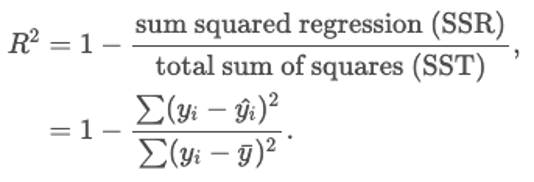

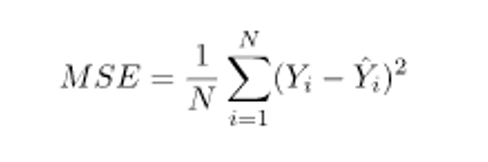

In [17]:
# Evaluation with r2_square:
from sklearn.metrics import r2_score

# Making Predictions of y value
y_train_pred = lm.predict(X_train)
y_test_pred = lm.predict(X_test)

# Comparing the r^2 value of both train and test data
print(r2_score(y_train,y_train_pred))
print(r2_score(y_test,y_test_pred))

0.8157933136480389
0.7921031601245662


##### The R² value on test data is within 5% of the R² value on training data.

Another evaluation metric is Mean Squared error:
MSE is an estimator measures the average of error squares i.e. the average squared difference between the estimated values and true value. It is a risk function, corresponding to the expected value of the squared error loss. It is always non – negative and values close to zero are better. 

In [18]:
# Evaluation with MSE:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_test_pred)
print(mse)

4.077556371826949


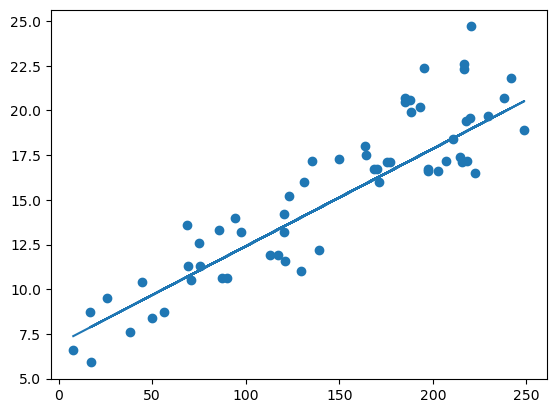

In [19]:
# Visualization:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred)
plt.show()